# Environment

In [1]:
import sys
from pathlib import Path
import sqlite3
module_path = Path("../01_Functions_classes_and_variables").resolve()
sys.path.append(str(module_path))

from simulation_data_functions import *
from data_exploration_functions import *
from data_operations_functions import *

import matplotlib.pyplot as plt
from spreg import ML_Lag
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
from econml.dml import CausalForestDML

from esda.moran import Moran


from sklearn.ensemble import RandomForestRegressor
from causalml.inference.meta import BaseSRegressor
from econml.dml import DML, LinearDML, SparseLinearDML, CausalForestDML
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import PolynomialFeatures

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor

from sklearn.metrics import r2_score

In [2]:
repo_path_wndws = Path("../").resolve()
repo_path_unix = repo_path_wndws.as_posix() 
repo_path_r_string = repo_path_unix.replace("/", '\\')

# Data

In [13]:
dict_of_combs = {

    'a': [12,10,4,6,4,5, None],
    'b': [16,10,4,7,4,5,None],
    'c': [20,10,4,8,4,5,None],
    'd': [20,12,4,7,4,6,None],
    'e': [20,14,4,7,4,7,2],
    
    'f': [20,16,4,7,4,7,None],
    'g': [20,18,4,8,4,7,3],
    'h': [20,20,4,8,4,7,None],
    'i': [22,20,4,9,4,7,4],
    'j': [24,20,4,9,4,7,6],
    'j': [26,20,4,10,4,7,5],

    'k': [28,20,4,11,4,7,4],
    'l': [30,20,4,13,4,6,None],
    'm': [32,20,4,13,4,7,2],
    'n': [34,20,4,13,4,7,4],
    'o': [36,20,4,13,4,7,6],

    'p': [38,20,4,13,4,7,8],
    'q': [40,20,4,13,4,7,10],
}

In [14]:
connection_link_var = repo_path_r_string + r'\03_simulated_data\simulated_data_ysamp_size.sqlite'
dict_of_gdfs = {}
for i in dict_of_combs:

        df = import_non_spatial_data_frame(
                connection_link = connection_link_var,
                df_to_return_name =  i
        )
        gdf = gpd.GeoDataFrame(
                df,
                geometry=gpd.points_from_xy(df["x"], df["y"]),
                crs="EPSG:3857"
                )
        
        dict_of_gdfs[i] = gdf

In [15]:
dict_of_gdfs.keys()

dict_keys(['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q'])

<Axes: >

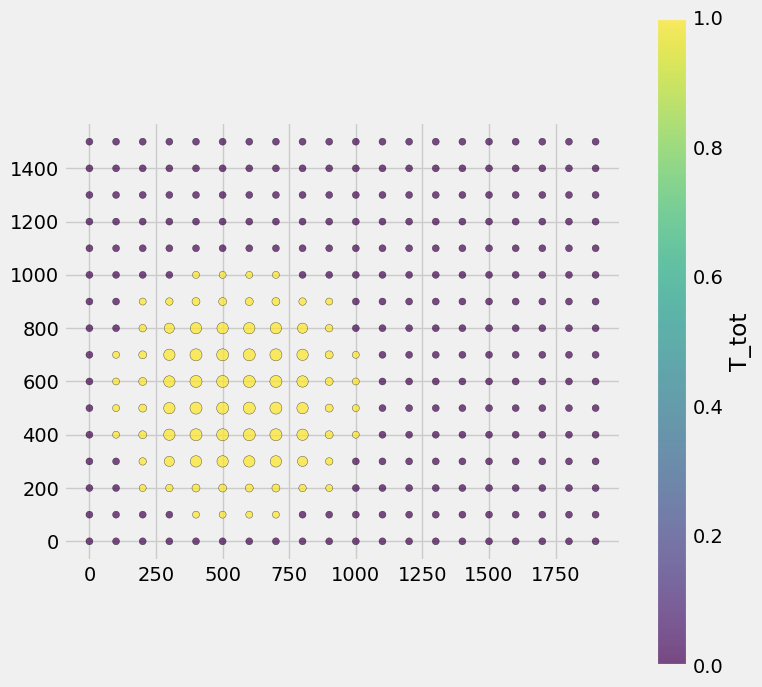

In [16]:

temp_gdf = dict_of_gdfs['f'].copy()
temp_gdf['spill2'] = temp_gdf['spill'] + 0.5
plot_gdf_points(temp_gdf, size_col='spill2',
    color_col='T_tot')

<Axes: >

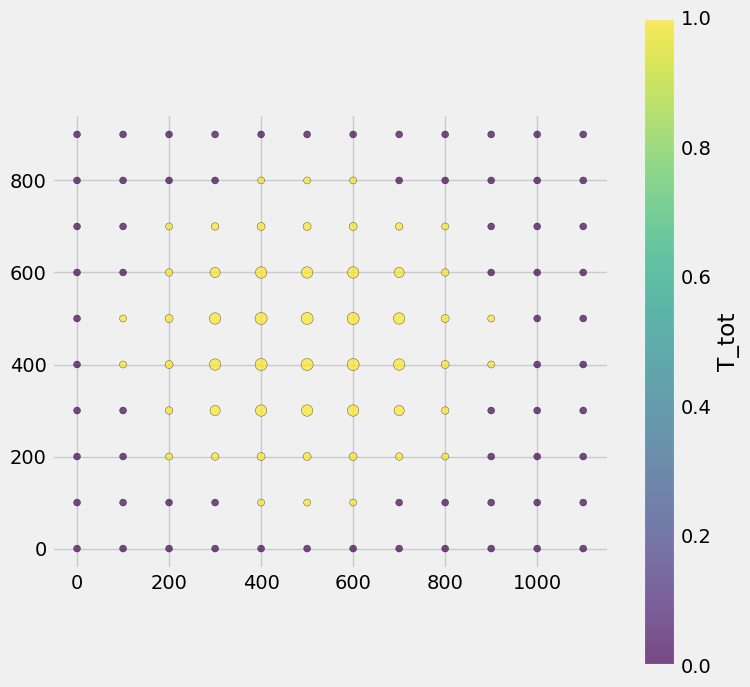

In [17]:

temp_gdf = dict_of_gdfs['a'].copy()
temp_gdf['spill2'] = temp_gdf['spill'] + 0.5
plot_gdf_points(temp_gdf, size_col='spill2',
    color_col='T_tot')

<Axes: >

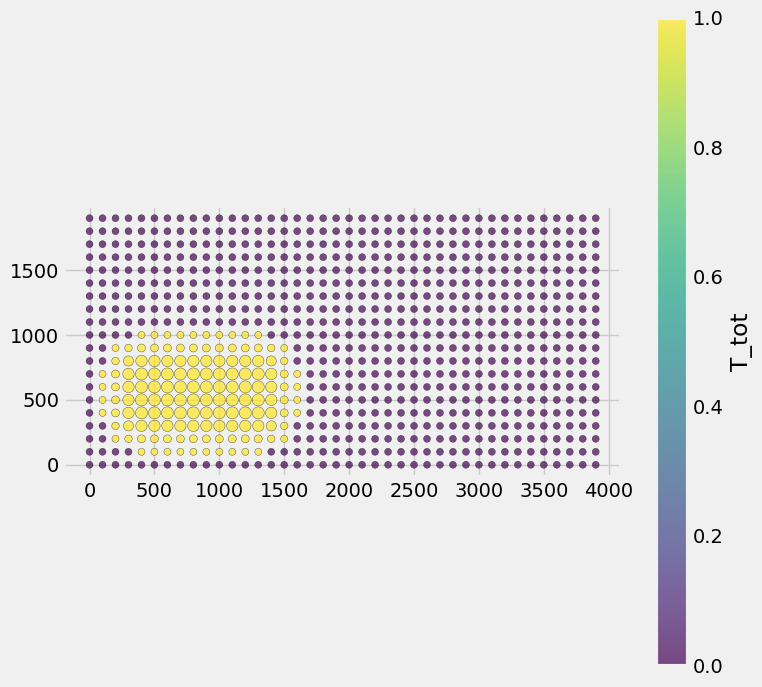

In [18]:

temp_gdf = dict_of_gdfs['q'].copy()
temp_gdf['spill2'] = temp_gdf['spill'] + 0.5
plot_gdf_points(temp_gdf, size_col='spill2',
    color_col='T_tot')

# Modelling causal inference

In [19]:
replacing_dict_0_ring = {0:'treated_inner_ring', 1:'treated_outer_ring1', 
                                             2:'treated_outer_ring2'
                                             }

replacing_dict_odr_ring = {'T':'treated_inner_ring', 
                                                                        'ODR_1':'treated_outer_ring1', 
                                                                        'ODR_2':'treated_outer_ring2',
                                                                        
                                                                          }

In [21]:
list_of_output_dfs = []
for i in  dict_of_gdfs.keys():
        
    # =========================================================
    # 0. Data preparation
    # =========================================================

    temp_gdf = dict_of_gdfs[i].copy()

    temp_gdf['t_tot_cat3'] =temp_gdf['T_tot_cat']
    temp_gdf.loc[temp_gdf['T_tot_cat']=='treated_outer_ring3', 't_tot_cat3'] = 'control'

    df_effectbase = pd.DataFrame({
                    'ring':['treated_inner_ring', 'treated_outer_ring1', 'treated_outer_ring2'#,'treated_outer_ring3',
                            #'treated_outer_ring4'
                            ],
                'true_effect':[temp_gdf[temp_gdf['T'] == 1]['tau'].mean(), temp_gdf[temp_gdf['ODR_1'] == 1]['tau'].mean(), 
                                temp_gdf[temp_gdf['ODR_2'] == 1]['tau'].mean()#, 
                                #temp_gdf[temp_gdf['ODR_3'] == 1]['tau'].mean(), 
                                ],
                })


    X = temp_gdf[["C1","C2"]].values
    T_M= temp_gdf['t_tot_cat3'].values
    T_M= T_M.astype(str)
    Y = temp_gdf['Y_dep_var_ns'].values

    T_mult = temp_gdf[[ 
            'T', 'ODR_1','ODR_2',
            #'ODR_3',
            #'treated_outer_ring4'
            ]].to_numpy()

    T_D_id = temp_gdf[[ 
            'T', 'Cont_T_N'
            ]].to_numpy()


    Xdf_did = temp_gdf[['T', 'ODR_1','ODR_2',
                        #'ODR_3', 
                "C1","C2"
            ]]
    X_did = sm.add_constant(Xdf_did)
    y_did = temp_gdf['Y_dep_var_ns']


    # =========================================================
    # 1. Multi-treatment S-Learner (distance rings)
    # =========================================================


    mS_learn = BaseSRegressor(RandomForestRegressor(n_estimators=160, max_depth=10, random_state=42), control_name = 'control')

    ite_mS_learn = mS_learn.fit_predict(X, T_M, Y)


    ITE_df_mSlearn = pd.DataFrame(ite_mS_learn).rename(columns = {0:'treated_inner_ring', 1:'treated_outer_ring1', 
                                                2:'treated_outer_ring2', 
                                                #3:'treated_outer_ring3',
                                                })
    ITE_df_mSlearn['treated'] = T_M


    df_multi_treatment_effects_Slearn = make_treatment_effects_df(ITE_df_mSlearn,  [ 'treated_inner_ring','treated_outer_ring1',
                'treated_outer_ring2'
                #,'treated_outer_ring3', 
                ],'mSlearn', treated_col='treated')


    df_multi_effect_pre1 = df_effectbase.merge(df_multi_treatment_effects_Slearn, on = 'ring', how= 'left')

    # =========================================================
    # 2. Multi-treatment Causal Forest DML (distance rings)
    # =========================================================

    mCF = CausalForestDML(model_y=RandomForestRegressor(n_estimators=100, max_depth=3, min_samples_leaf=20),
                        model_t=MultiOutputRegressor(RandomForestRegressor(n_estimators=100,
                                                                                max_depth=3,
                                                                                min_samples_leaf=20)),
                        cv=None,
                        criterion='mse', n_estimators=1000,
                        min_samples_leaf=10,
                        min_impurity_decrease=0.001,
                        random_state=123)

    mCF.tune(Y, T_mult, X=X, 
            #W=W
            )
    mCF.fit(Y, T_mult, X=X, 
            #W=W
            )

    mCF_pred = mCF.const_marginal_effect(X)
    ITE_mCF=pd.DataFrame(mCF_pred).rename(columns = replacing_dict_0_ring)

    ITE_mCF['treated'] = T_M
    df_multi_treatment_effects_mCF = make_treatment_effects_df(ITE_mCF,  ['treated_inner_ring','treated_outer_ring1',
                'treated_outer_ring2'
                #,'treated_outer_ring3', 
                #'treated_outer_ring4'
                ],'mCF', treated_col='treated')

    df_multi_effect_pre2 = df_multi_effect_pre1.merge(df_multi_treatment_effects_mCF, on = 'ring', how= 'left')

    # =========================================================
    # 3. Double-treatment Causal Forest DML (inverse distance from treated)
    # =========================================================

    dCF = CausalForestDML(model_y=RandomForestRegressor(n_estimators=100, max_depth=3, min_samples_leaf=20),
                        model_t=MultiOutputRegressor(RandomForestRegressor(n_estimators=100,
                                                                                max_depth=3,
                                                                                min_samples_leaf=20)),
                        cv=None,
                        criterion='mse', n_estimators=1000,
                        min_samples_leaf=10,
                        min_impurity_decrease=0.001,
                        random_state=123)

    dCF.tune(Y, T_D_id, X=X, 
            #W=W
            )
    dCF.fit(Y, T_D_id, X=X, 
            #W=W
            )

    dCF_pred = dCF.const_marginal_effect(X)
    ITE_dCF=pd.DataFrame(dCF_pred).rename(columns = {0:'treated_inner_ring', 1:'treated_outer_rings', 

                                                })

    ITE_dCF['treated'] = T_M

    ITE_dCF['treated_outer_ring1'] = ITE_dCF['treated_outer_rings']
    ITE_dCF['treated_outer_ring2'] = ITE_dCF['treated_outer_rings']/2
    #ITE_dCF['treated_outer_ring3'] = ITE_dCF['treated_outer_rings']/3

    df_multi_treatment_effects_dCF = make_treatment_effects_df(ITE_dCF,  ['treated_inner_ring','treated_outer_ring1',
                'treated_outer_ring2',
                #'treated_outer_ring3', 
                #'treated_outer_ring4'
                ],'dCF', treated_col='treated')

    df_multi_effect_pre3 = df_multi_effect_pre2.merge(df_multi_treatment_effects_dCF, on = 'ring', how= 'left')


    # =========================================================
    # 4. Multi-treatment Difference in Differences (distance rings)
    # =========================================================

    model_did = sm.OLS(y_did, X_did)
    results_did = model_did.fit()

    coef_df_did = pd.DataFrame({
        "ring": results_did.params.index,
        "att_mDiD": results_did.params.values,
        "se_mDiD": results_did.bse.values
    })

    coef_df_did = coef_df_did[coef_df_did['ring'].isin(['T', 
                                                                'ODR_1', 'ODR_2',
                                                                #'ODR_3',
                                                                ])].copy()
    coef_df_did['ring'] = coef_df_did['ring'].replace(replacing_dict_odr_ring)

    df_multi_effect_temp = df_multi_effect_pre3.merge(coef_df_did, on = 'ring', how= 'left')
    df_multi_effect_temp['sample_size'] = dict_of_combs[i][0]*dict_of_combs[i][1]
    df_multi_effect_temp = df_multi_effect_temp[['sample_size', 'ring',
            'true_effect',
            'att_mSlearn',
            'se_mSlearn',
            'att_mCF',
            'se_mCF',
            'att_dCF',
            'se_dCF',
            'att_mDiD',
            'se_mDiD']]
    list_of_output_dfs.append(df_multi_effect_temp)
df_results = pd.concat(list_of_output_dfs)
#df_results['rho'] = df_results['rho'].str[2:].astype(float)/1000
df_results

c:\Users\andre\AppData\Local\Programs\Python\Python313\Lib\site-packages\econml\sklearn_extensions\linear_model.py:1815: UserWarning: Co-variance matrix is underdetermined. Inference will be invalid!
  warnings.warn("Co-variance matrix is underdetermined. Inference will be invalid!")
c:\Users\andre\AppData\Local\Programs\Python\Python313\Lib\site-packages\econml\sklearn_extensions\linear_model.py:1815: UserWarning: Co-variance matrix is underdetermined. Inference will be invalid!
  warnings.warn("Co-variance matrix is underdetermined. Inference will be invalid!")


,sample_size,ring,true_effect,att_mSlearn,se_mSlearn,att_mCF,se_mCF,att_dCF,se_dCF,att_mDiD,se_mDiD
0,120,treated_inner_ring,1.500000,0.525188,0.202012,1.028925,0.050868,1.028440,0.037052,0.943409,0.359183
1,120,treated_outer_ring1,0.864346,0.395652,0.124883,0.915185,0.035999,0.909008,0.033737,0.717020,0.283591
2,120,treated_outer_ring2,0.268216,-0.074834,0.055632,-0.169241,0.026482,0.438269,0.012021,-0.122215,0.244463
0,160,treated_inner_ring,1.500000,0.497552,0.134303,1.299987,0.072408,1.322267,0.067720,1.222520,0.321031
1,160,treated_outer_ring1,0.935983,0.356249,0.105695,0.576511,0.069768,0.540170,0.070428,0.649876,0.266216
2,160,treated_outer_ring2,0.286280,-0.141199,0.068095,0.023988,0.055319,0.251224,0.023684,-0.175524,0.233913
0,200,treated_inner_ring,1.500000,1.444822,0.155416,1.857411,0.144285,1.842264,0.141054,1.858461,0.287795
1,200,treated_outer_ring1,0.940451,0.632548,0.108625,1.328715,0.070797,1.283762,0.076603,1.171894,0.245731
2,200,treated_outer_ring2,0.274928,-0.000194,0.038765,0.178563,0.034384,0.666209,0.042025,0.234218,0.218927
0,240,treated_inner_ring,1.500000,1.264683,0.143111,1.522935,0.041825,1.529362,0.046400,1.509945,0.262654


# Results visualization

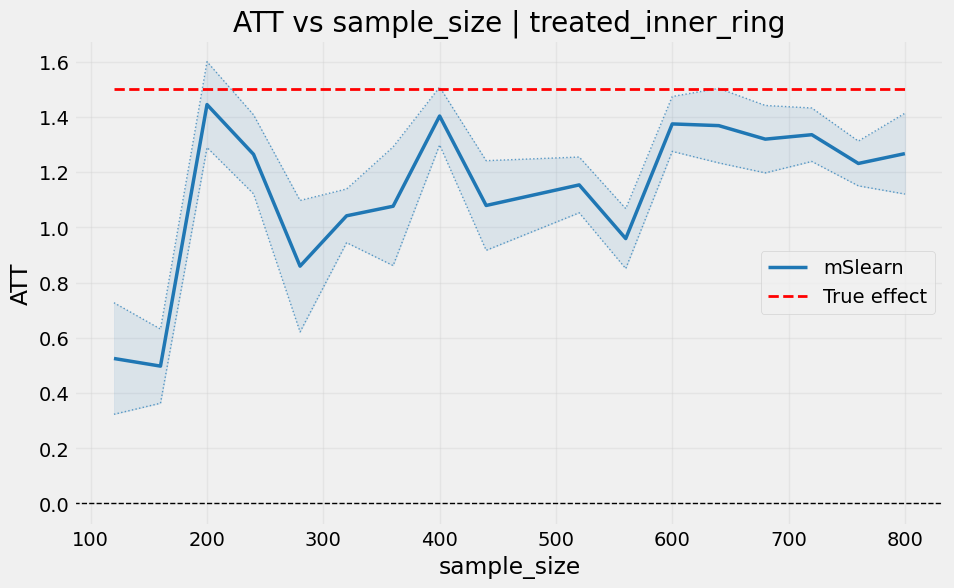

In [25]:
models = {
    "mSlearn": ("att_mSlearn", "se_mSlearn"),
    # "mCF": ("att_mCF", "se_mCF"),
    # 'dCF' : ('att_dCF', 'se_dCF'),
    # "DiD": ("att_mDiD", "se_mDiD")
}

plot_att_by_param(
    df_results,
    param_col="sample_size",
    ring_value="treated_inner_ring",
    models_dict=models
)

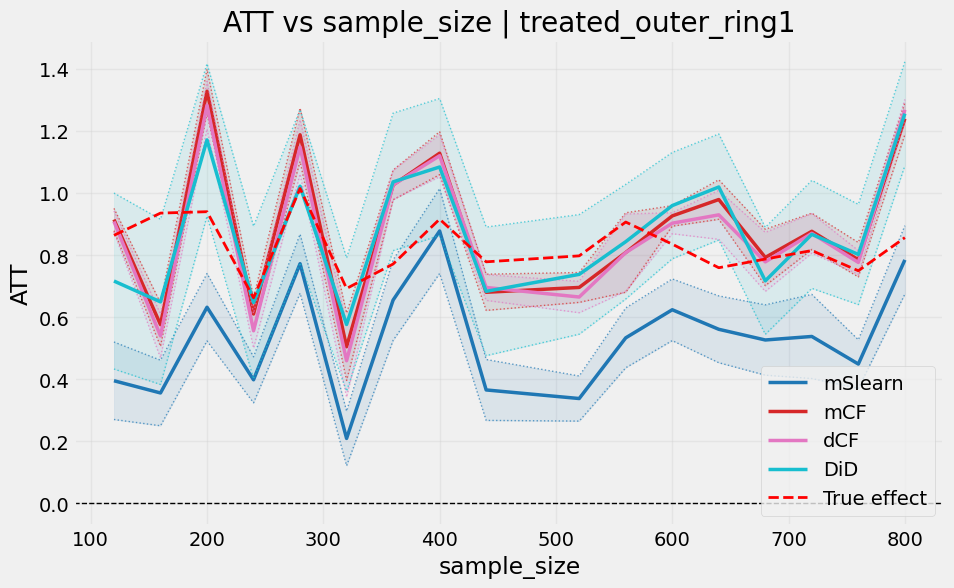

In [23]:
plot_att_by_param(
    df_results,
    param_col="sample_size",
    ring_value="treated_outer_ring1",
    models_dict=models
)

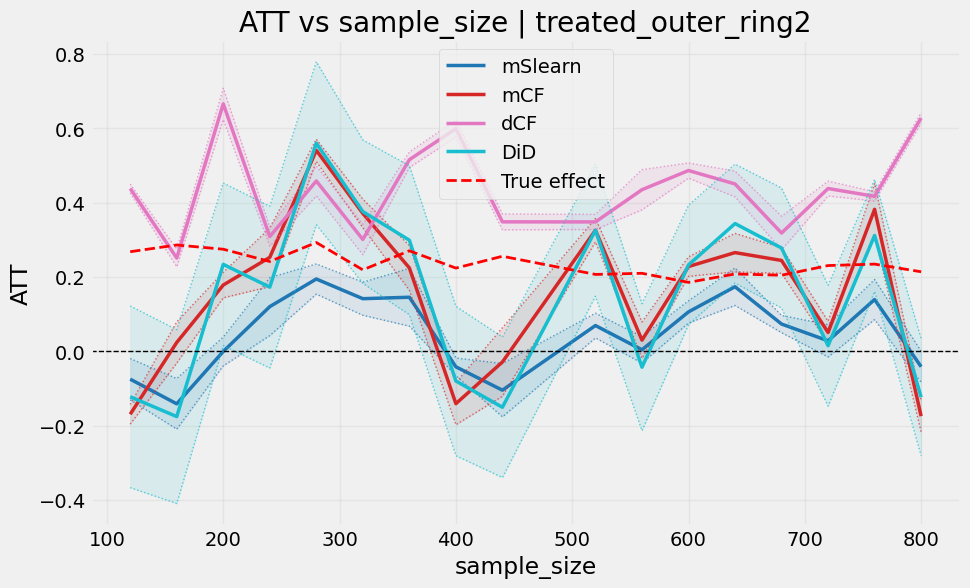

In [24]:
plot_att_by_param(
    df_results,
    param_col="sample_size",
    ring_value="treated_outer_ring2",
    models_dict=models
)